
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 CLINICAL PERFORMANCE METRICS (Threshold = 0.295)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Recall (Sensitivity): 96.41%
 Accuracy:             81.13%
 F1-Score:             83.62%
 AUC Score:            88.21%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


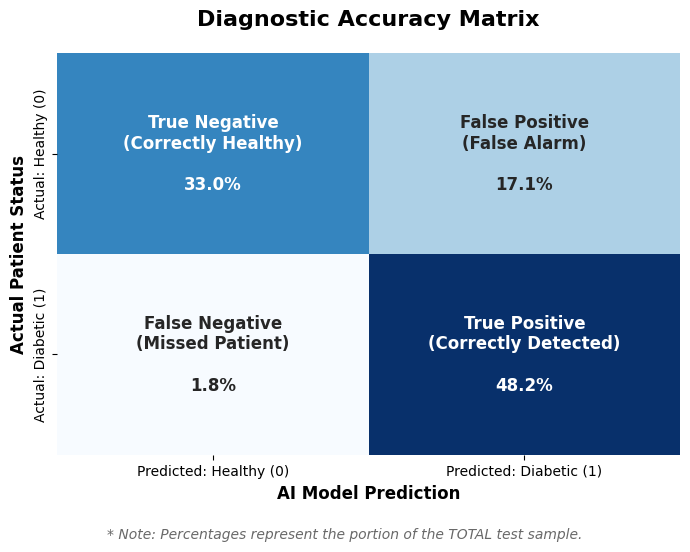


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 GLOBAL MODEL EXPLAINABILITY (Risk Factors)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


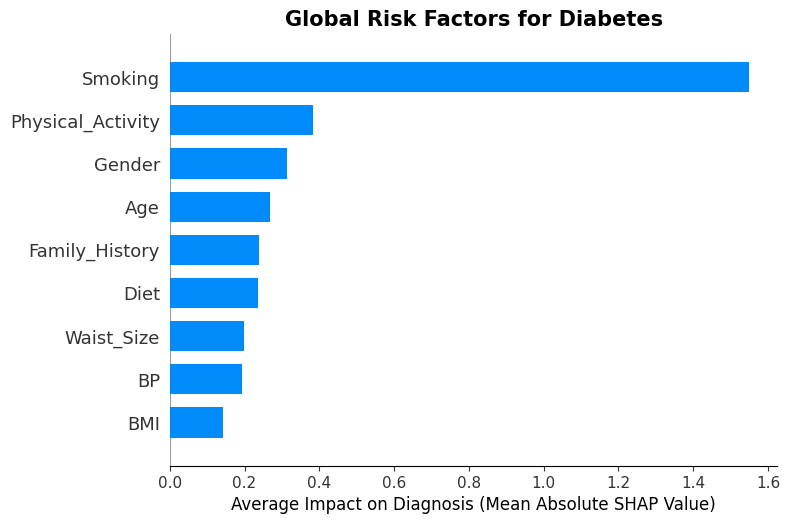


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 INDIVIDUAL PATIENT DIAGNOSIS REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Patient ID:          #350
 Risk Probability:    81.76%
 Decision Threshold:  29.50%
 Final Diagnosis:     🔴 HIGH RISK (Diabetic)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 LOCAL MODEL EXPLAINABILITY (Risk Factors) 



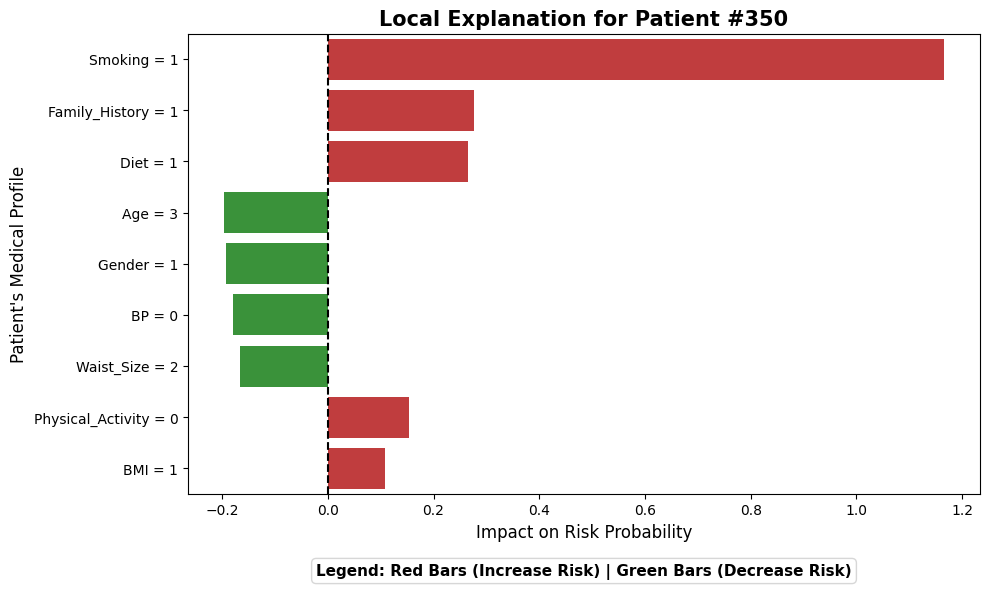

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# =========================================================
# 1. Data Loading and Preparation
# =========================================================
file_path = '/content/Survey dataset labelled balnced data 3-5-2020.xls'
df = pd.read_excel(file_path)

if 'Region' in df.columns:
    df = df.drop(columns=['Region'])

X = df.drop(columns=['Class'])
y = df['Class']

# =========================================================
# 2. Data Splitting (Train / Validation / Test)
# =========================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# =========================================================
# 3. Model Training (Optimized Clinical XGBoost)
# =========================================================
model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=1.3,
    n_estimators=600,
    learning_rate=0.02,
    max_depth=6,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.05,
    reg_lambda=1,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# =========================================================
# 4. Clinical Performance Evaluation
# =========================================================
# Hardcoded optimal clinical threshold derived from empirical validation
CLINICAL_THRESHOLD = 0.295

y_test_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_test_proba >= CLINICAL_THRESHOLD).astype(int)

rec = recall_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_test_proba)

print("\n" + "━"*50)
print(f" CLINICAL PERFORMANCE METRICS (Threshold = {CLINICAL_THRESHOLD})")
print("━"*50)
print(f" Recall (Sensitivity): {rec * 100:.2f}%")
print(f" Accuracy:             {acc * 100:.2f}%")
print(f" F1-Score:             {f1 * 100:.2f}%")
print(f" AUC Score:            {auc * 100:.2f}%")
print("━"*50)

# =========================================================
# 5. Diagnostic Confusion Matrix
# =========================================================
cm = confusion_matrix(y_test, y_pred)
cm_percentage = cm / np.sum(cm)

group_names = [
    'True Negative\n(Correctly Healthy)',
    'False Positive\n(False Alarm)',
    'False Negative\n(Missed Patient)',
    'True Positive\n(Correctly Detected)'
]

group_percentages = ["{0:.1%}".format(value) for value in cm_percentage.flatten()]
labels = np.asarray([f"{v1}\n\n{v2}" for v1, v2 in zip(group_names, group_percentages)]).reshape(2, 2)

plt.figure(figsize=(7, 5.5))
sns.heatmap(cm_percentage, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predicted: Healthy (0)', 'Predicted: Diabetic (1)'],
            yticklabels=['Actual: Healthy (0)', 'Actual: Diabetic (1)'],
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Diagnostic Accuracy Matrix', fontsize=16, weight='bold', pad=20)
plt.xlabel('AI Model Prediction', fontsize=12, weight='bold')
plt.ylabel('Actual Patient Status', fontsize=12, weight='bold')

plt.figtext(0.5, 0.01, '* Note: Percentages represent the portion of the TOTAL test sample.',
            wrap=True, horizontalalignment='center', fontsize=10, style='italic', color='dimgray')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# =========================================================
# 6. Global Model Explainability (SHAP)
# =========================================================
print("\n" + "━"*50)
print(" GLOBAL MODEL EXPLAINABILITY (Risk Factors)")
print("━"*50)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global Risk Factors for Diabetes", fontsize=15, weight='bold')
plt.xlabel("Average Impact on Diagnosis (Mean Absolute SHAP Value)", fontsize=12)
plt.show()

# =========================================================
# 7. Local Explanation (Individual Patient Report)
# =========================================================
patient_index = random.randint(0, len(X_test) - 1)
prediction, risk_prob = y_pred[patient_index], y_test_proba[patient_index]

print("\n" + "━"*50)
print(" INDIVIDUAL PATIENT DIAGNOSIS REPORT")
print("━"*50)
print(f" Patient ID:          #{patient_index}")
print(f" Risk Probability:    {risk_prob*100:.2f}%")
print(f" Decision Threshold:  {CLINICAL_THRESHOLD*100:.2f}%")
print(f" Final Diagnosis:     {'🔴 HIGH RISK (Diabetic)' if prediction == 1 else '🟢 LOW RISK (Healthy)'}")
print("━"*50)

print("\n LOCAL MODEL EXPLAINABILITY (Risk Factors) \n")

local_features = [f"{col} = {val}" for col, val in zip(X_test.columns, X_test.iloc[patient_index])]
local_df = pd.DataFrame({'Feature_Value': local_features, 'Contribution': shap_values[patient_index, :]})
local_df = local_df.reindex(local_df.Contribution.abs().sort_values(ascending=False).index).head(10)

colors = ['#d62728' if val > 0 else '#2ca02c' for val in local_df['Contribution']]
plt.figure(figsize=(10, 6))
sns.barplot(data=local_df, x='Contribution', y='Feature_Value', hue='Feature_Value', palette=colors, legend=False)
plt.axvline(0, color='black', linestyle='--', linewidth=1.5)

plt.title(f"Local Explanation for Patient #{patient_index}", fontsize=15, weight='bold')
plt.xlabel("Impact on Risk Probability", fontsize=12)
plt.ylabel("Patient's Medical Profile", fontsize=12)
plt.text(0.5, -0.15, 'Legend: Red Bars (Increase Risk) | Green Bars (Decrease Risk)',
         transform=plt.gca().transAxes, fontsize=11, weight='bold',
         verticalalignment='top', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='lightgray'))
plt.tight_layout()
plt.show()